Total frames     : 3119
Valid detections : 3119  (100.0% of frames)
Time span        : 0.000 s → 62.360 s
theta range      : -2.5254 to 1.2873 rad



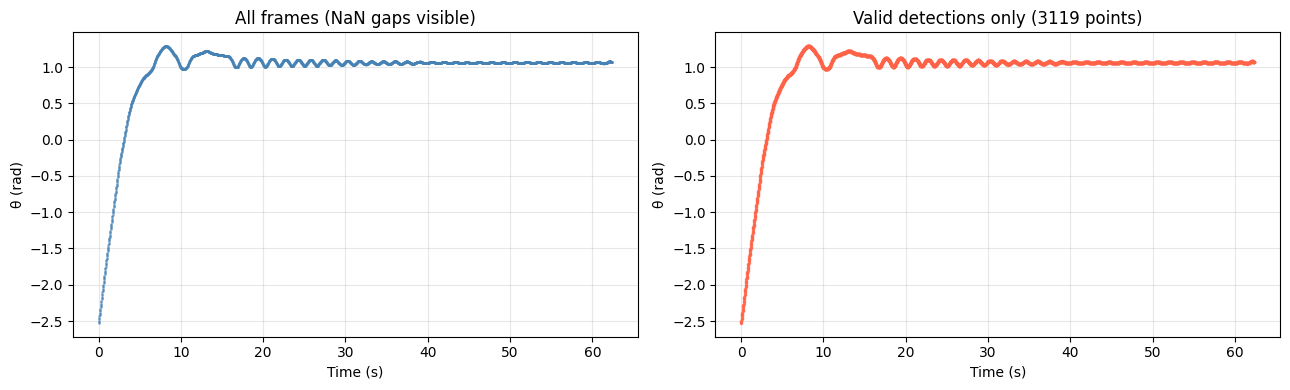

Diagnostic plot saved → signal_diagnostic.png
Spiral starts at index 274  |  t = 5.480 s  |  θ = -0.2074 rad
Points in spiral: 2845

Rough period estimate: 0.5200 s  |  min_dist = 15 samples
Step 1 → 84 peaks detected

Step 2 → Fit: A₀ = 0.20173 ± 7.62e-03,  t_e = 12.43896 ± 7.04e-01 s
Step 3 → T = 0.68130 ± 2.17e-01 s  |  ω_res = 9.2224 rad/s  |  f = 1.4678 Hz

Step 4 → α = 0.008717 ± 2.82e-03
Step 5 → γ = 0.000000 ± 2.42e-10

  FINAL:  γ = 0.0000 ± 2.42e-10   (I = 4.6515225881017465e-09)


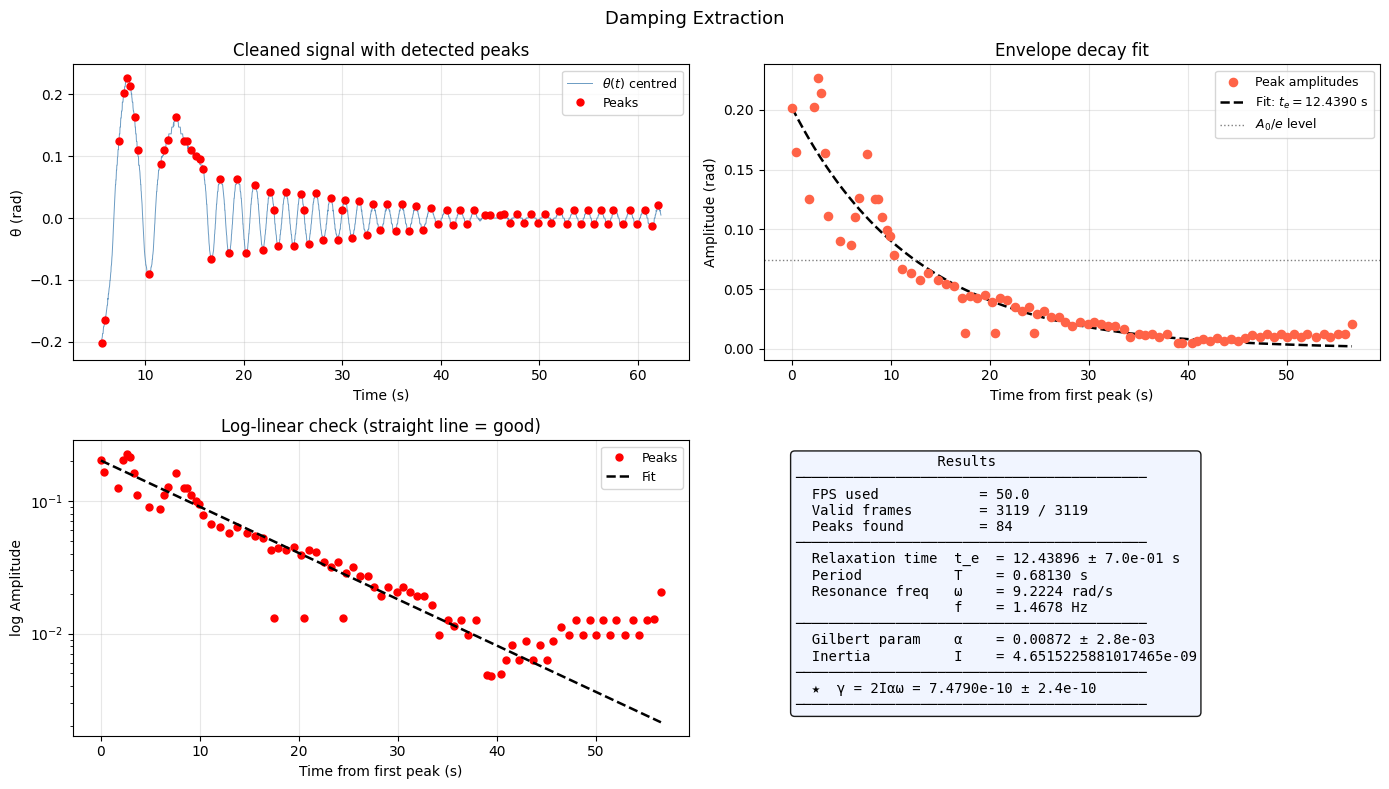

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

df = pd.read_csv('tracking_output_12.csv')
FPS = 50
df['time_s'] = df['frame'] / FPS

# Drop rows where theta_rad was not detected (NaN)
df_clean = df[['time_s', 'theta_rad']].dropna(subset=['theta_rad']).copy()
df_clean = df_clean.sort_values('time_s').reset_index(drop=True)

t     = df_clean['time_s'].values
theta = df_clean['theta_rad'].values

print(f"Total frames     : {len(df)}")
print(f"Valid detections : {len(df_clean)}  ({100*len(df_clean)/len(df):.1f}% of frames)")
print(f"Time span        : {t[0]:.3f} s → {t[-1]:.3f} s")
print(f"theta range      : {theta.min():.4f} to {theta.max():.4f} rad\n")

if len(df_clean) < 10:
    print("⚠  Very few valid frames. The tracker struggled to detect the marker.")
    print("   Consider re-running tracking with adjusted blob/threshold params.")

# ─────────────────────────────────────────────────────────────
#  DIAGNOSTIC PLOT — see what the cleaned signal looks like
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df['time_s'], df['theta_rad'], '.', ms=2, color='steelblue', alpha=0.5)
axes[0].set_title('All frames (NaN gaps visible)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('θ (rad)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, theta, '.', ms=3, color='tomato', alpha=0.7)
axes[1].set_title(f'Valid detections only ({len(df_clean)} points)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('θ (rad)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('signal_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Diagnostic plot saved → signal_diagnostic.png")

# ─────────────────────────────────────────────────────────────
#  1. UNWRAP theta if it wraps around ±π, then centre on 0
# at turning point: theta = theta, omega = 0
# ─────────────────────────────────────────────────────────────
theta_unwrap = np.unwrap(theta)
theta_centred = theta_unwrap - np.median(theta_unwrap)   # centre around equilibrium
dt_raw   = np.diff(t)
omega_raw = np.diff(theta_centred) / dt_raw

# First zero-crossing of omega = start of oscillation
zc = np.where(np.diff(np.sign(omega_raw)))[0]

if len(zc) > 0:
    spiral_start = zc[0] + 1          # +1 because diff shifts index by 1
else:
    spiral_start = 0                   # fallback: use all data
    print("⚠  No zero-crossing found — using full dataset")

# Trim
t             = t[spiral_start:]
theta_centred = theta_centred[spiral_start:]
print(f"Spiral starts at index {spiral_start}  |  t = {t[0]:.3f} s  |  θ = {theta_centred[0]:.4f} rad")
print(f"Points in spiral: {len(t)}\n")

theta_abs = np.abs(theta_centred)

# ─────────────────────────────────────────────────────────────
#  2. ADAPTIVE PEAK DETECTION
# ─────────────────────────────────────────────────────────────
# Estimate a rough period from zero-crossings
signs = np.sign(theta_centred)
zc_idx = np.where(np.diff(signs) != 0)[0]
# linear interpolation for sub-sample zero-crossing times
t_zero = t[zc_idx] + dt_raw[zc_idx] * (
    -theta_centred[zc_idx] / (theta_centred[zc_idx + 1] - theta_centred[zc_idx])
)
# then use t_zero instead of t[zero_cross_idx]:
half_periods = np.diff(t_zero)
T_rough = 2.0 * np.median(half_periods)

if len(t_zero) >= 4:
    half_periods = np.diff(t_zero)
    T_rough = 2.0 * np.median(half_periods)
    dt_median = np.median(np.diff(t))               # median time step (uneven gaps!)
    min_dist = max(int(0.6 * T_rough / dt_median), 2)
    print(f"Rough period estimate: {T_rough:.4f} s  |  min_dist = {min_dist} samples")
else:
    min_dist = max(len(t) // 20, 2)
    T_rough = None
    print(f"⚠  Few zero-crossings found. Using min_dist = {min_dist}")

#peak detection
peaks_idx, _ = find_peaks(
    theta_abs,
    distance=min_dist,
    height=np.percentile(theta_abs[theta_abs > 0], 10)   # bottom quartile cutoff
)

# ADD this block after find_peaks:
t_peaks_interp = np.zeros(len(peaks_idx), dtype=float)
A_peaks_interp = np.zeros(len(peaks_idx), dtype=float)

for j, idx in enumerate(peaks_idx):
    if idx == 0 or idx == len(theta_abs) - 1:
        t_peaks_interp[j] = t[idx]
        A_peaks_interp[j] = theta_abs[idx]
    else:
        # fit parabola to 3 points around peak
        y0, y1, y2 = theta_abs[idx-1], theta_abs[idx], theta_abs[idx+1]
        t0_, t1_, t2_ = t[idx-1], t[idx], t[idx+1]
        # quadratic peak location
        denom = (y0 - 2*y1 + y2)
        if denom != 0:
            dt_offset = 0.5 * (y0 - y2) / (2 * denom) * (t2_ - t0_)
        else:
            dt_offset = 0
        t_peaks_interp[j] = t[idx] + dt_offset
        A_peaks_interp[j] = y1 - (y0 - y2)**2 / (8 * denom) if denom != 0 else y1

# use these instead:
t_peaks = t_peaks_interp
A_peaks = A_peaks_interp

print(f"Step 1 → {len(peaks_idx)} peaks detected\n")

if len(peaks_idx) < 4:
    print("⚠  Still too few peaks after cleaning.")
    print("   Possible causes:")
    print("   - Wrong FPS value (change FPS above)")
    print("   - Signal is not oscillating (check diagnostic plot)")
    print("   - Tracking gaps too large (need re-tracking with lower threshold)")
    raise SystemExit("Not enough data for damping fit.")

# ─────────────────────────────────────────────────────────────
#  3. EXPONENTIAL DECAY FIT  A(t) = A0 * exp(-t / t_e)
# ─────────────────────────────────────────────────────────────
def exp_decay(t, A0, t_e):
    return A0 * np.exp(-t / t_e)

t0 = t_peaks[0]
try:
    popt, pcov = curve_fit(
        exp_decay,
        t_peaks - t0,
        A_peaks,
        p0=[A_peaks[0], (t_peaks[-1] - t0) / 2.0],
        bounds=([0, 1e-9], [np.inf, np.inf]),
        maxfev=10000
    )
    A0_fit, t_e = popt
    A0_err, te_err = np.sqrt(np.diag(pcov))
    print(f"Step 2 → Fit: A₀ = {A0_fit:.5f} ± {A0_err:.2e},  t_e = {t_e:.5f} ± {te_err:.2e} s")
except RuntimeError as e:
    print(f"Fit failed: {e}")
    raise

# ─────────────────────────────────────────────────────────────
#  4. RESONANCE FREQUENCY
# ─────────────────────────────────────────────────────────────
T_avg     = np.mean(np.diff(t_peaks))
T_std     = np.std(np.diff(t_peaks))
omega_res = 2.0 * np.pi / T_avg
f_res     = 1.0 / T_avg

print(f"Step 3 → T = {T_avg:.5f} ± {T_std:.2e} s  |  ω_res = {omega_res:.4f} rad/s  |  f = {f_res:.4f} Hz")

# ─────────────────────────────────────────────────────────────
#  5. GILBERT α  &  VISCOUS γ
# ─────────────────────────────────────────────────────────────
rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)
alpha = 1 / (omega_res * t_e)
alpha_err = alpha * np.sqrt((te_err/t_e)**2 + (T_std/T_avg)**2)

gamma = 2.0 * I * alpha * omega_res
gamma_err = 2.0 * I * alpha_err * omega_res

print(f"\nStep 4 → α = {alpha:.6f} ± {alpha_err:.2e}")
print(f"Step 5 → γ = {gamma:.6f} ± {gamma_err:.2e}")
print(f"\n{'='*50}")
print(f"  FINAL:  γ = {gamma:.4f} ± {gamma_err:.2e}   (I = {I})")
print(f"{'='*50}")

# ─────────────────────────────────────────────────────────────
#  FINAL FIGURE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(r'Damping Extraction', fontsize=13)

t_fit_arr = np.linspace(0, t_peaks[-1] - t0, 400)
A_fit_arr = exp_decay(t_fit_arr, A0_fit, t_e)

ax = axes[0, 0]
ax.plot(t, theta_centred, lw=0.7, color='steelblue', alpha=0.8, label=r'$\theta(t)$ centred')
ax.plot(t[peaks_idx], theta_centred[peaks_idx], 'ro', ms=5, label='Peaks')
ax.set_xlabel('Time (s)'); ax.set_ylabel('θ (rad)')
ax.set_title('Cleaned signal with detected peaks'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(t_peaks - t0, A_peaks, color='tomato', s=35, zorder=5, label='Peak amplitudes')
ax.plot(t_fit_arr, A_fit_arr, 'k--', lw=1.8, label=fr'Fit: $t_e={t_e:.4f}$ s')
ax.axhline(A0_fit / np.e, color='gray', ls=':', lw=1, label='$A_0/e$ level')
ax.set_xlabel('Time from first peak (s)'); ax.set_ylabel('Amplitude (rad)')
ax.set_title('Envelope decay fit'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.semilogy(t_peaks - t0, A_peaks, 'ro', ms=5, label='Peaks')
ax.semilogy(t_fit_arr, A_fit_arr, 'k--', lw=1.8, label='Fit')
ax.set_xlabel('Time from first peak (s)'); ax.set_ylabel('log Amplitude')
ax.set_title('Log-linear check (straight line = good)'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.axis('off')
summary = (
    f"{'Results':^42}\n{'─'*42}\n"
    f"  FPS used            = {FPS:.1f}\n"
    f"  Valid frames        = {len(df_clean)} / {len(df)}\n"
    f"  Peaks found         = {len(peaks_idx)}\n"
    f"{'─'*42}\n"
    f"  Relaxation time  t_e  = {t_e:.5f} ± {te_err:.1e} s\n"
    f"  Period           T    = {T_avg:.5f} s\n"
    f"  Resonance freq   ω    = {omega_res:.4f} rad/s\n"
    f"                   f    = {f_res:.4f} Hz\n"
    f"{'─'*42}\n"
    f"  Gilbert param    α    = {alpha:.5f} ± {alpha_err:.1e}\n"
    f"  Inertia          I    = {I}\n"
    f"{'─'*42}\n"
    f"  ★  γ = 2Iαω = {gamma:.4e} ± {gamma_err:.1e}\n"
    f"{'─'*42}"
)
ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=10,
        va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))

plt.tight_layout()
plt.show()


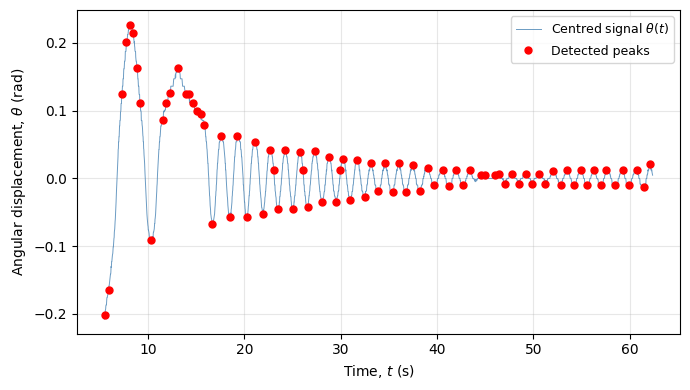

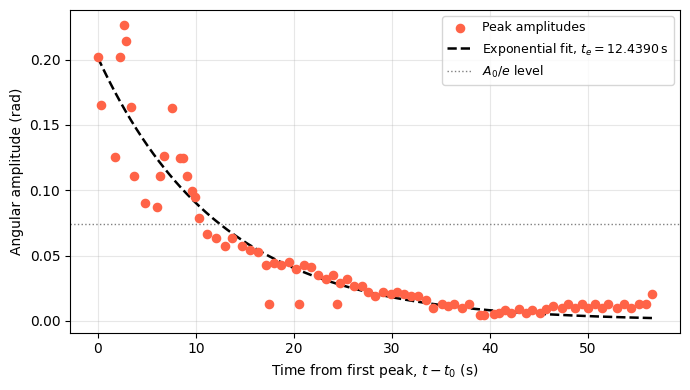

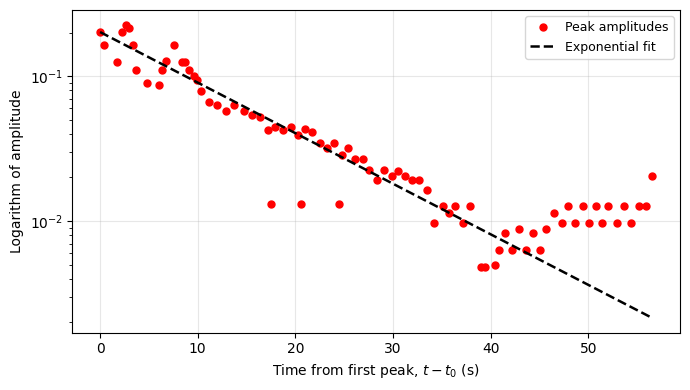

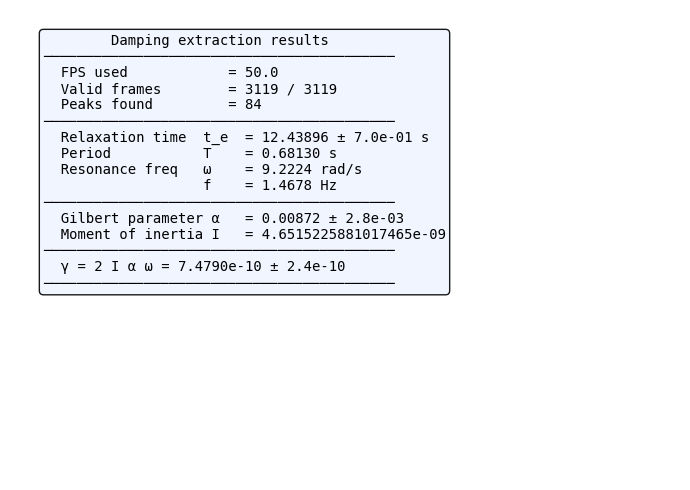

Saved → damping_cleaned_signal_with_peaks.png, damping_envelope_decay_fit.png, damping_log_linear_check.png, damping_extraction_summary.png


In [ ]:
# 1) Cleaned signal with detected peaks
plt.figure(figsize=(7, 4))
plt.plot(t, theta_centred, lw=0.7, color='steelblue', alpha=0.8,
         label=r'Centred signal $\theta(t)$')
plt.plot(t[peaks_idx], theta_centred[peaks_idx], 'ro', ms=5, label='Detected peaks')
plt.xlabel('Time, $t$ (s)')
plt.ylabel(r'Angular displacement, $\theta$ (rad)')
#plt.title('Cleaned angular displacement signal with detected peaks')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('damping_cleaned_signal_with_peaks.png',
            dpi=400, bbox_inches='tight')

# 2) Envelope decay fit
plt.figure(figsize=(7, 4))
plt.scatter(t_peaks - t0, A_peaks, color='tomato', s=35,
            zorder=5, label='Peak amplitudes')
plt.plot(t_fit_arr, A_fit_arr, 'k--', lw=1.8,
         label=fr'Exponential fit, $t_e = {t_e:.4f}\,\mathrm{{s}}$')
plt.axhline(A0_fit / np.e, color='gray', ls=':', lw=1,
            label=r'$A_0 / e$ level')
plt.xlabel('Time from first peak, $t - t_0$ (s)')
plt.ylabel('Angular amplitude (rad)')
#plt.title('Exponential envelope decay fit')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('damping_envelope_decay_fit.png',
            dpi=400, bbox_inches='tight')

# 3) Log-linear check
plt.figure(figsize=(7, 4))
plt.semilogy(t_peaks - t0, A_peaks, 'ro', ms=5, label='Peak amplitudes')
plt.semilogy(t_fit_arr, A_fit_arr, 'k--', lw=1.8, label='Exponential fit')
plt.xlabel('Time from first peak, $t - t_0$ (s)')
plt.ylabel('Logarithm of amplitude')
#plt.title('Log–linear check of exponential decay')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('damping_log_linear_check.png',
            dpi=400, bbox_inches='tight')

# 4) Text-only summary panel
plt.figure(figsize=(7, 5))
summary = (
    f"{'Damping extraction results':^42}\n{'─'*42}\n"
    f"  FPS used            = {FPS:.1f}\n"
    f"  Valid frames        = {len(df_clean)} / {len(df)}\n"
    f"  Peaks found         = {len(peaks_idx)}\n"
    f"{'─'*42}\n"
    f"  Relaxation time  t_e  = {t_e:.5f} ± {te_err:.1e} s\n"
    f"  Period           T    = {T_avg:.5f} s\n"
    f"  Resonance freq   ω    = {omega_res:.4f} rad/s\n"
    f"                   f    = {f_res:.4f} Hz\n"
    f"{'─'*42}\n"
    f"  Gilbert parameter α   = {alpha:.5f} ± {alpha_err:.1e}\n"
    f"  Moment of inertia I   = {I}\n"
    f"{'─'*42}\n"
    f"  γ = 2 I α ω = {gamma:.4e} ± {gamma_err:.1e}\n"
    f"{'─'*42}"
)
plt.axis('off')
plt.text(0.05, 0.95, summary, transform=plt.gca().transAxes,
         fontsize=10, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.9))
plt.tight_layout()
plt.savefig('damping_extraction_summary.png',
            dpi=400, bbox_inches='tight')

plt.show()
print("Saved →",
      "damping_cleaned_signal_with_peaks.png,",
      "damping_envelope_decay_fit.png,",
      "damping_log_linear_check.png,",
      "damping_extraction_summary.png")


Arrays ready for U_mag cell: tv, thv, omega_s, alpha_s — all spiral-only (2571 points)


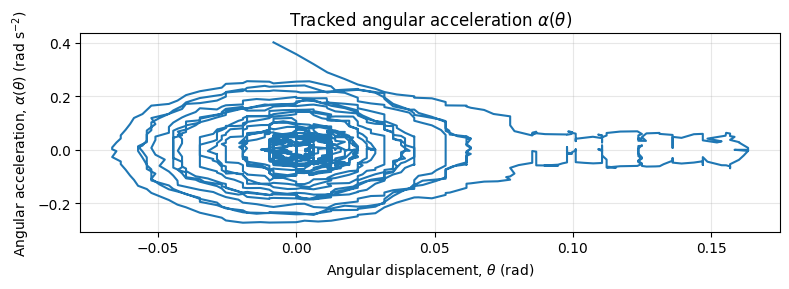

In [ ]:
from scipy.signal import savgol_filter

# Trim
t             = t[spiral_start:]
theta_centred = theta_centred[spiral_start:]

valid  = np.isfinite(theta_centred) & np.isfinite(t)
tv     = t[valid]
thv    = theta_centred[valid]

omega       = np.gradient(thv, tv)
omega_s     = savgol_filter(omega, window_length=21, polyorder=3)
alpha_raw   = np.gradient(omega_s, tv)
alpha_s     = savgol_filter(alpha_raw, window_length=21, polyorder=3)

print(f"\nArrays ready for U_mag cell: tv, thv, omega_s, alpha_s — all spiral-only ({len(tv)} points)")
plt.figure(figsize=(8, 3))
plt.plot(thv, omega_s, lw=1.5)
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Angular acceleration, $\alpha(\theta)$ (rad s$^{-2}$)')
plt.title(r'Tracked angular acceleration $\alpha(\theta)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Alpha(t) vs theta.png', dpi=400, bbox_inches='tight')
plt.show()

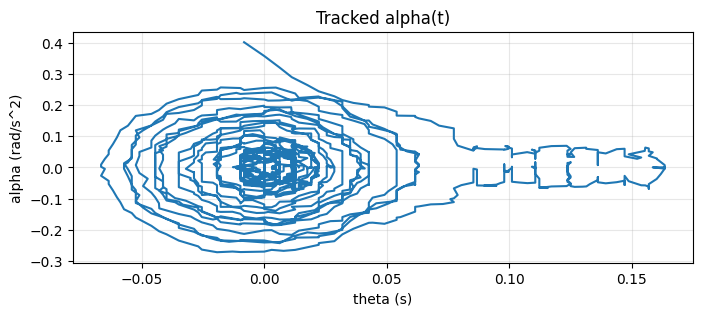

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(thv, omega_s, lw=1.5)
plt.xlabel("theta (s)")
plt.ylabel("alpha (rad/s^2)")
plt.title("Tracked alpha(t)")
plt.grid(True, alpha=0.3)
plt.show()

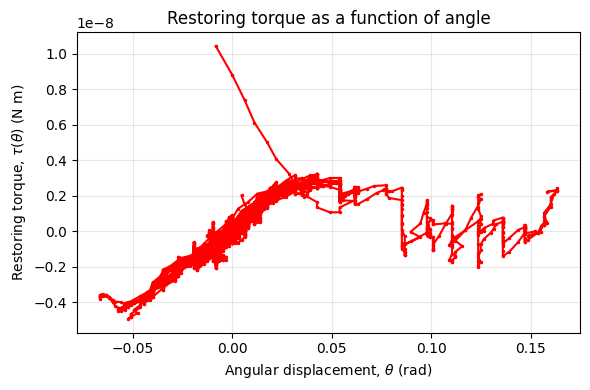

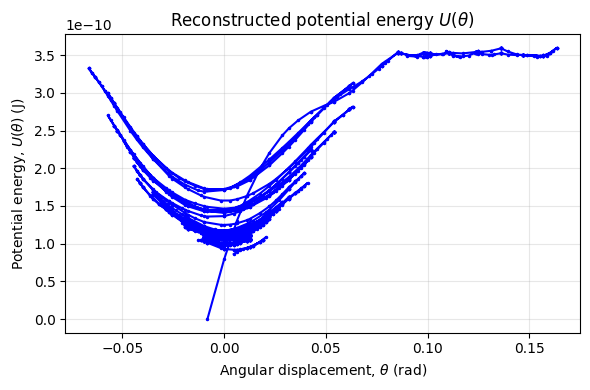

In [ ]:
from scipy.integrate import cumulative_trapezoid
## Culmulative trapezoid
# tv, thv, alpha come from the valid segment
# tv: time, thv: continuous theta_cont[valid], alpha: from omega_s on tv

rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)

tau_inst = I * alpha_s
tau_diss = gamma * omega_s
tau_total = - (tau_inst + tau_diss)


# U_mag(theta) from torque:  U = -∫ tau dθ
##### this is the delta_Umag, so need to add together
U_theta = cumulative_trapezoid(tau_total, thv, initial=0)

# --- 1) Restoring torque vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(thv, tau_total, 'r.-', ms=3)
plt.title(r'Restoring torque as a function of angle')
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Restoring torque, $\tau(\theta)$ (N m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('restoring_torque_vs_angle.png', dpi=400, bbox_inches='tight')

# --- 2) Reconstructed potential vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(thv, U_theta, 'b.-', ms=3)
plt.title(r'Reconstructed potential energy $U(\theta)$')
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstructed_potential_vs_angle.png', dpi=400, bbox_inches='tight')

plt.show()



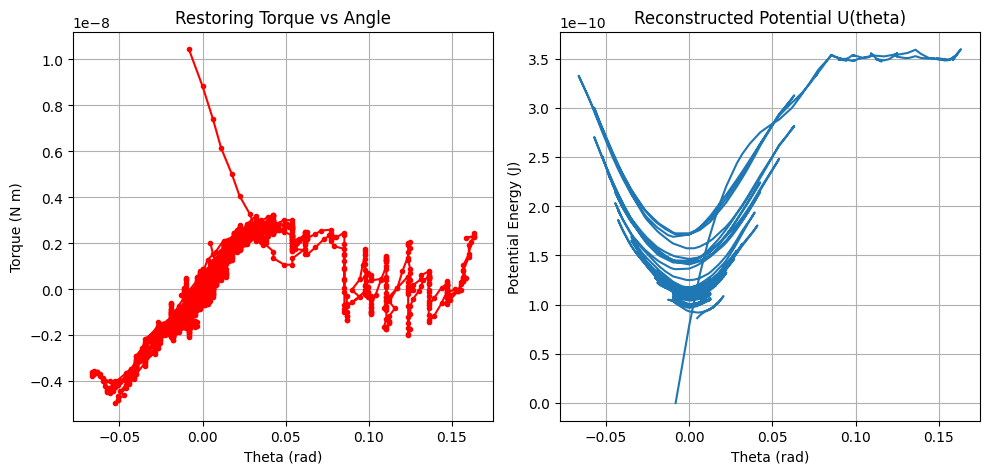

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thv, tau_total, 'r.-')
plt.title("Restoring Torque vs Angle")
plt.xlabel("Theta (rad)")
plt.ylabel("Torque (N m)")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(thv, U_theta, '-')
plt.title("Reconstructed Potential U(theta)")
plt.xlabel("Theta (rad)")
plt.ylabel("Potential Energy (J)")
plt.grid(True)
plt.tight_layout()
#plt.savefig(".png", dpi=400, bbox_inches="tight")
plt.show()

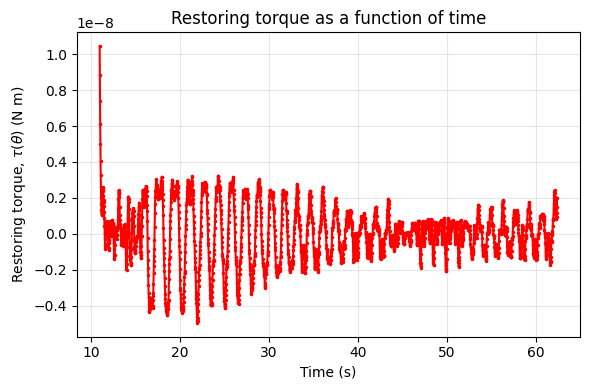

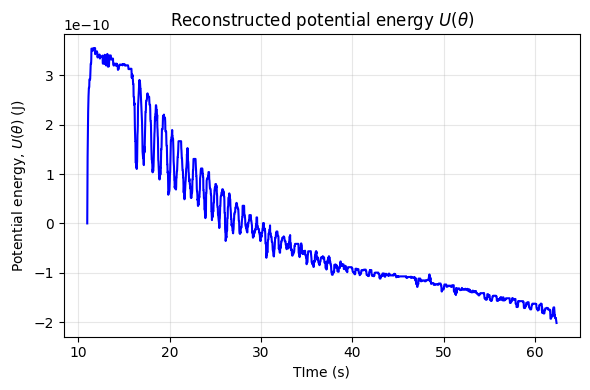

In [ ]:
# tv, thv, alpha come from the valid segment
# tv: time, thv: continuous theta_cont[valid], alpha: from omega_s on tv

rho = 2070
m = rho * np.pi * (1.1e-3) * ((7.8e-3)**2 - (7.0e-3)**2)
I = 0.5 * m * ((7.8e-3)**2 + (7.0e-3)**2)

tau_inst = I * alpha_s
tau_diss = gamma * omega_s
tau_total = - (tau_inst + tau_diss)

dt = np.diff(tv)

theta_mid = (thv[:-1] + thv[1:]) / 2
omega_mid = np.diff(thv) / dt
alpha_mid = np.diff(omega_s) / dt

tau_inst_mid  = I * alpha_mid
tau_diss_mid  = gamma * omega_mid
tau_total_mid = -(tau_inst_mid + tau_diss_mid)

d_theta = np.diff(thv)
delta_U = tau_total_mid * d_theta
U_theta = np.cumsum(np.insert(delta_U, 0, 0))

# --- 1) Restoring torque vs angle ---

plt.figure(figsize=(6, 4))
plt.plot(tv, tau_total, 'r.-', ms=3)
plt.title(r'Restoring torque as a function of time')
plt.xlabel(r'Time (s)')
plt.ylabel(r'Restoring torque, $\tau(\theta)$ (N m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('restoring_torque_vs_time.png', dpi=400, bbox_inches='tight')

# --- 2) Reconstructed potential vs angle (NOT time) ---

plt.figure(figsize=(6, 4))
plt.plot(tv, U_theta, 'b-')
plt.title(r'Reconstructed potential energy $U(\theta)$')
plt.xlabel(r'TIme (s)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstructed_potential_vs_time.png', dpi=400, bbox_inches='tight')

plt.show()



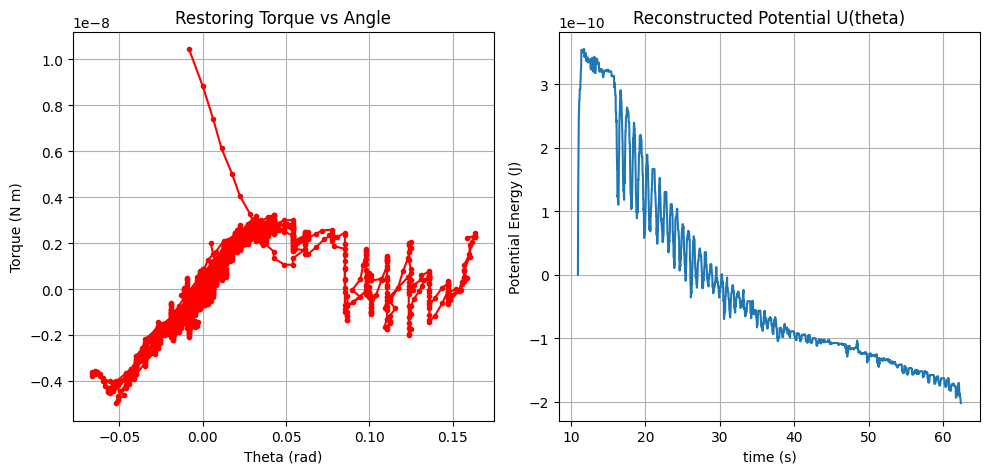

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(thv, tau_total, 'r.-')
plt.title("Restoring Torque vs Angle")
plt.xlabel("Theta (rad)")
plt.ylabel("Torque (N m)")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(tv, U_theta, '-')
plt.title("Reconstructed Potential U(theta)")
plt.xlabel("time (s)")
plt.ylabel("Potential Energy (J)")
plt.grid(True)
plt.tight_layout()
#plt.savefig(".png", dpi=400, bbox_inches="tight")
plt.show()

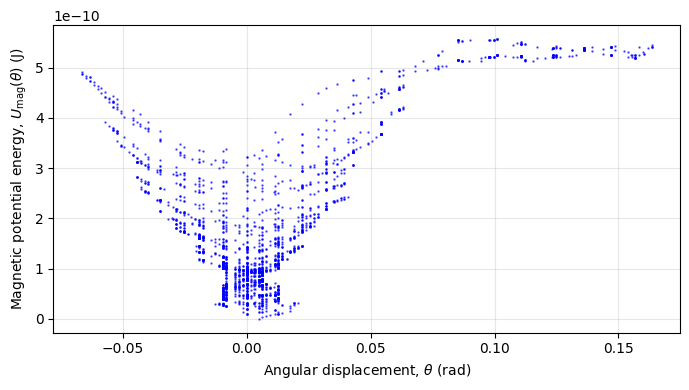

In [ ]:
# ── Paper method: step-by-step accumulation along trajectory ──
# tau_total_mid and d_theta are already time-ordered — no sorting needed

delta_U = tau_total_mid * d_theta
U_theta = np.cumsum(np.insert(delta_U, 0, 0))
U_theta_shifted = U_theta - np.min(U_theta)

# ── Plot U vs θ (time-ordered trajectory traces the landscape) ──
plt.figure(figsize=(7, 4))
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.6)
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
#plt.title(r'Reconstructed magnetic potential $U_{\mathrm{mag}}(\theta)$ ' r'from the Dumont et al. method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Reconstructed Umag.png", dpi=400, bbox_inches="tight")
plt.show()

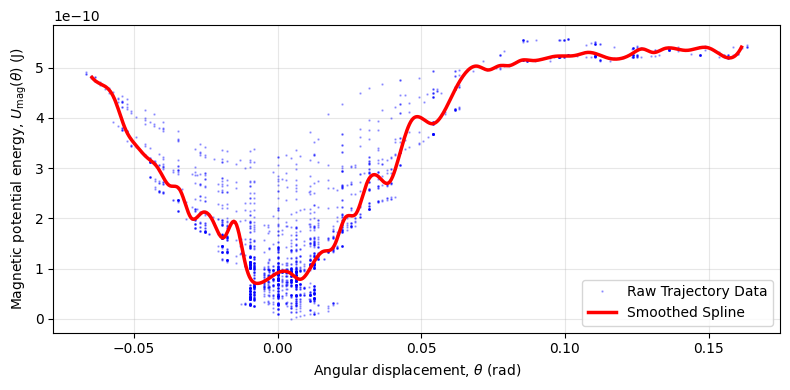

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.stats import binned_statistic

# ── Paper method: step-by-step accumulation along trajectory ──
delta_U = tau_total_mid * d_theta
U_theta = np.cumsum(np.insert(delta_U, 0, 0))
U_theta_shifted = U_theta - np.min(U_theta)

# ── PREPPING DATA FOR THE SPLINE (BINNING METHOD) ──
# 1. Chop the theta axis into 60 bins and find the median U value in each bin.
# (Using 'median' ignores the extreme scattered granules at the top and bottom)
num_bins = 60
bin_medians, bin_edges, _ = binned_statistic(thv, U_theta_shifted, statistic='median', bins=num_bins)

# 2. Find the center x-coordinate of each bin
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 3. Clean up the bins (remove any empty bins where the rotor didn't travel)
valid = ~np.isnan(bin_medians)
thv_clean = bin_centers[valid]
U_clean = bin_medians[valid]

# 4. Create the Spline from the clean, binned medians
# Because the data is now a clean line, we can use a very small smoothing factor 's'
spline_smooth = UnivariateSpline(thv_clean, U_clean, s=1e-22)

# Create a smooth x-axis for plotting the lines
thv_new = np.linspace(np.min(thv_clean), np.max(thv_clean), 500)

# ── Plot U vs θ ──
plt.figure(figsize=(8, 4))

# Plot the original raw data as a faded background cloud
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.3, label='Raw Trajectory Data')

# (Optional: Uncomment the line below if you want to see the black median dots the spline is following!)
# plt.plot(thv_clean, U_clean, 'k.', ms=5, label='Binned Medians')

# Plot the smoothed spline
plt.plot(thv_new, spline_smooth(thv_new), 'r-', linewidth=2.5, label='Smoothed Spline')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

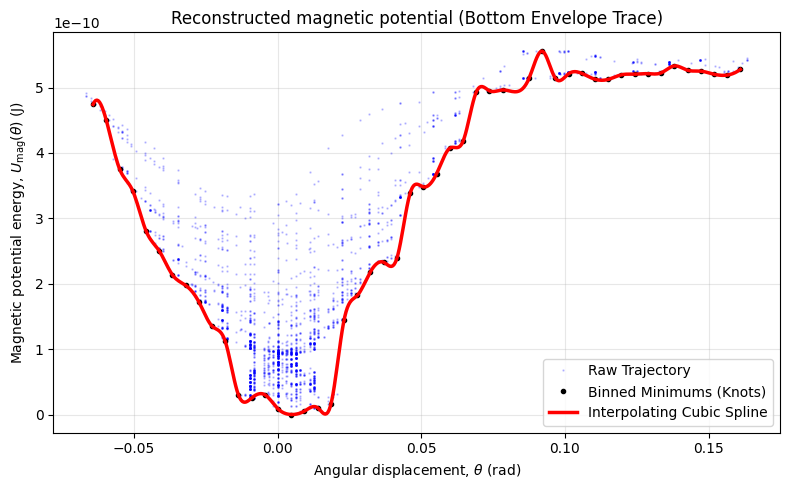

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
from scipy.interpolate import CubicSpline


# --- 1. Sort and Bin the Data (UPDATED) ---
num_bins = 50

bin_vals, bin_edges, _ = binned_statistic(
    thv, U_theta_shifted, statistic=min, bins=num_bins
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Drop NaNs to keep the x-array strictly increasing
valid = ~np.isnan(bin_vals)
x_clean = bin_centers[valid]
y_clean = bin_vals[valid]

# --- 2. Fit the STRICT Interpolating Cubic Spline ---
cs = CubicSpline(x_clean, y_clean)

# Generate a high-resolution x-axis to draw the curve
x_smooth = np.linspace(x_clean.min(), x_clean.max(), 500)
y_smooth = cs(x_smooth)

# --- 3. Plotting ---
plt.figure(figsize=(8, 5))

# Raw data in the background
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.2, label='Raw Trajectory')

# Binned points (Now tracing the MINIMUM values)
plt.plot(x_clean, y_clean, 'k.', ms=6, label='Binned Minimums (Knots)')

# The Interpolating Cubic Spline
plt.plot(x_smooth, y_smooth, 'r-', lw=2.5, label='Interpolating Cubic Spline')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
plt.title('Reconstructed magnetic potential (Bottom Envelope Trace)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

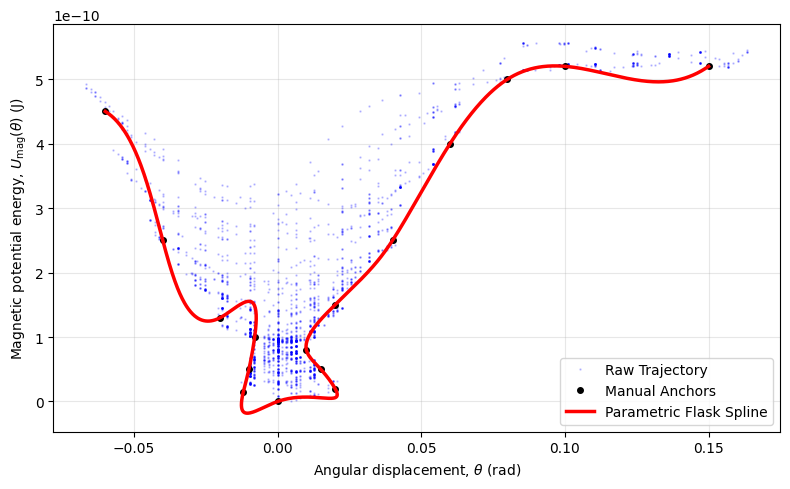

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

# --- 1. Define your manual anchor points ---
# I have estimated these coordinates based on your sketch to create the "flask" bottom.
# You can tweak these numbers to perfectly shape the bulb!
x_manual = [
    -0.06, -0.04, -0.02,   # Left slope down
    -0.008, -0.01, -0.012,         # Flaring OUT on the left
    0.0,                   # The absolute bottom dead center
    0.02, 0.015, 0.01,          # Flaring OUT on the right
    0.02, 0.04, 0.06,      # Right slope up
    0.08, 0.10, 0.15       # The flat top right tail
]

y_manual = [
    4.5e-10, 2.5e-10, 1.3e-10, # Left slope down
    1e-10, 0.5e-10, 0.14e-10,          # The left undercut
    0.0,                       # The bottom
    0.2e-10, 0.5e-10, 0.8e-10,         # The right undercut
    1.5e-10, 2.5e-10, 4.0e-10, # Right slope up
    5.0e-10, 5.2e-10, 5.2e-10  # The flat top right tail
]

# --- 2. Create the Parametric Spline ---
# splprep is used for 2D parametric curves. s=0 forces it through your exact points.
tck, u = splprep([x_manual, y_manual], s=0, k=3)

# Generate a smooth path (1000 points along the curve)
u_fine = np.linspace(0, 1, 1000)
x_smooth, y_smooth = splev(u_fine, tck)

# --- 3. Plotting ---
plt.figure(figsize=(8, 5))

# Raw data in the background
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.2, label='Raw Trajectory')

# Your manual anchor points
plt.plot(x_manual, y_manual, 'k.', ms=8, label='Manual Anchors')

# The resulting parametric shape
plt.plot(x_smooth, y_smooth, 'r-', lw=2.5, label='Parametric Flask Spline')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
#plt.title('Reconstructed magnetic potential (Parametric Shape)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

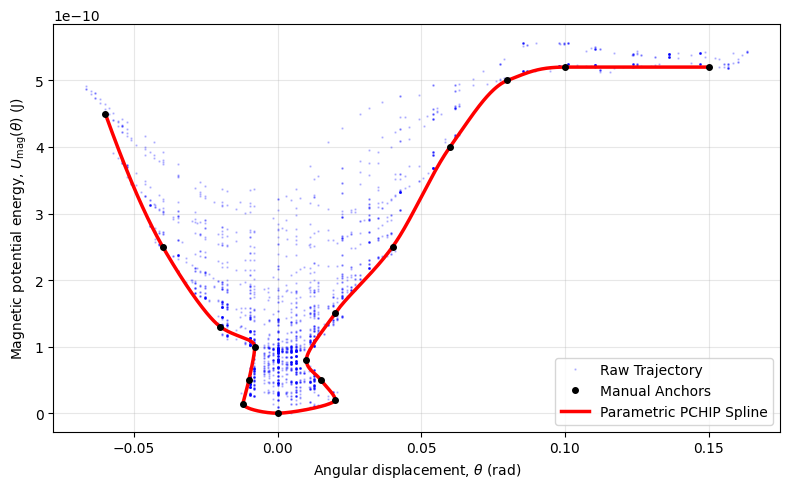

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# --- 1. Define your manual anchor points in YOUR exact order ---
x_manual = np.array([
    -0.06, -0.04, -0.02,
    -0.008, -0.01, -0.012,
    0.0,
    0.02, 0.015, 0.01,
    0.02, 0.04, 0.06,
    0.08, 0.10, 0.15
])

y_manual = np.array([
    4.5e-10, 2.5e-10, 1.3e-10,
    1e-10, 0.5e-10, 0.14e-10,
    0.0,
    0.2e-10, 0.5e-10, 0.8e-10,
    1.5e-10, 2.5e-10, 4.0e-10,
    5.0e-10, 5.2e-10, 5.2e-10
])

# --- 2. PARAMETRIC PCHIP (The Magic Fix) ---
# Create an artificial "step" variable t for the sequence of your dots (0 to 15)
t_manual = np.arange(len(x_manual))

# Interpolate x and y completely independently against the step number
pchip_x = PchipInterpolator(t_manual, x_manual)
pchip_y = PchipInterpolator(t_manual, y_manual)

# Generate a smooth, high-resolution array of steps
t_fine = np.linspace(0, len(x_manual) - 1, 1000)

# Calculate the smooth x and y paths
x_smooth = pchip_x(t_fine)
y_smooth = pchip_y(t_fine)

# --- 3. Plotting ---
plt.figure(figsize=(8, 5))

# (Assuming you still have thv and U_theta_shifted loaded, uncomment below to see the raw data)
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.2, label='Raw Trajectory')

# Your manual anchor points
plt.plot(x_manual, y_manual, 'k.', ms=8, label='Manual Anchors', zorder=5)

# The resulting parametric shape
plt.plot(x_smooth, y_smooth, 'r-', lw=2.5, label='Parametric PCHIP Spline')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Magnetic potential energy, $U_{\mathrm{mag}}(\theta)$ (J)')
#plt.title('Reconstructed magnetic potential')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("spline.png", dpi=400, bbox_inches="tight")
plt.show()

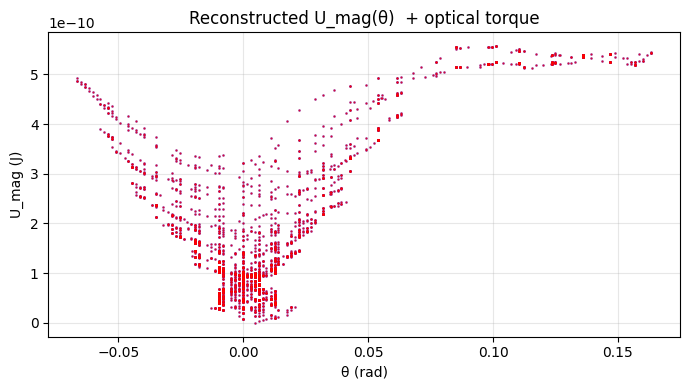

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.6)

theta_c = 0.05          # rad

c = 3e8
P_laser = 10          # W
lam = 405e-9            # m
#eta = 0.01              # guess: 1% of power absorbed by ring

P_abs = P_laser
tau0 = P_abs * lam / (2*np.pi*c)   # N·m

H = (thv >= theta_c).astype(float)
#tau0=1e-9

U_opt = tau0 * (thv - theta_c) * H
U_opt = tau0 * thv
U_tot = U_theta_shifted + U_opt

plt.xlabel('θ (rad)')
plt.ylabel('U_mag (J)')
#plt.title('Reconstructed U_mag(θ)  + optical torque')
plt.plot(thv, U_tot, 'r.', ms=1.5, alpha=0.6)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:23: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_9061/3829282679.py:23: SyntaxWarning: invalid escape sequence '\k'
  plt.plot(theta_theory, U_theory, 'r-', lw=1.5, label='Ideal Harmonic Potential ($U = \\frac{1}{2}\kappa\\theta^2$)')


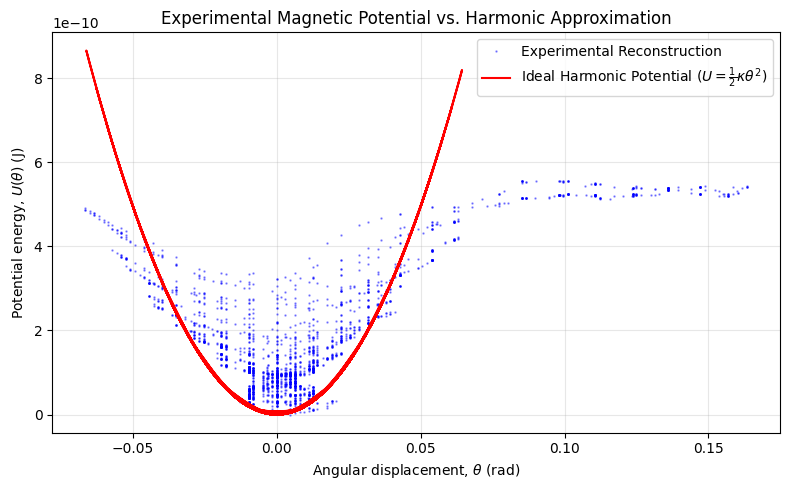

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

omega_0 = 2 * np.pi / T_avg
kappa = I * (omega_0)**2

decay_rate = gamma/(2*I)

#omega_0=np.sqrt(kappa/I)
omega_d=np.sqrt(omega_0**2 - decay_rate**2)
theta_theory_max = np.max(np.abs(thv))
theta_theory = theta_theory_max * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)
# Calculate the perfect harmonic potential (U = 0.5 * k * theta^2)
U_theory = 0.5 * kappa * (theta_theory)**2

# --- 3. Plot Them Together ---
plt.figure(figsize=(8, 5))

# Plot the experimental "fuzzy" data (alpha=0.4 makes the dots slightly transparent)
plt.plot(thv, U_theta_shifted, 'b.', ms=1.5, alpha=0.4, label='Experimental Reconstruction')

# Plot the perfect theoretical parabola right on top
plt.plot(theta_theory, U_theory, 'r-', lw=1.5, label='Ideal Harmonic Potential ($U = \\frac{1}{2}\kappa\\theta^2$)')

# Formatting
plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Potential energy, $U(\theta)$ (J)')
plt.title('Experimental Magnetic Potential vs. Harmonic Approximation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Umag Vs Harmonic.png", dpi=400, bbox_inches="tight")
plt.show()

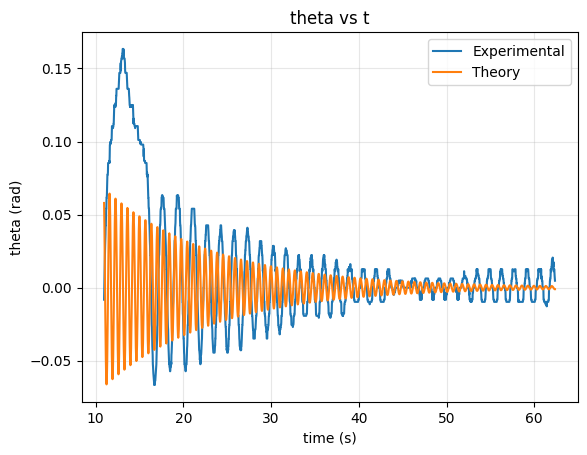

In [ ]:
from numpy.ma.core import exp
import matplotlib.pyplot as plt
import numpy as np

# --- 1. System Parameters ---
decay_rate = gamma/(2*I)

#omega_0=np.sqrt(kappa/I)
omega_d=np.sqrt(omega_0**2 - decay_rate**2)
#theta_theory = thv[0] * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)
theta_theory_max = np.max(np.abs(thv))
theta_theory = theta_theory_max * np.exp(-decay_rate* tv) * np.cos(omega_d*tv)


# Formatting
plt.xlabel('time (s)')
plt.ylabel('theta (rad)')
plt.title('theta vs t')
plt.plot(tv, thv, label = "Experimental")
plt.plot(tv, theta_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.savefig("my_plot.png", dpi=400, bbox_inches="tight")
plt.show()

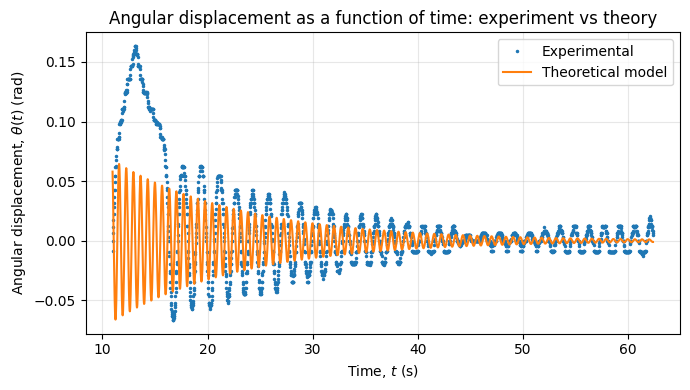

In [ ]:
# Example: window indices you actually plot
i0, i1 = 0, len(tv)          # or something like spiral_start:...
tv_window  = tv[i0:i1]
thv_window = thv[i0:i1]

theta_theory_max = np.max(np.abs(thv_window))
theta_theory = theta_theory_max * np.exp(-decay_rate * tv_window) * np.cos(omega_d * tv_window)


plt.figure(figsize=(7, 4))

plt.plot(tv, thv, '.', ms=3, label='Experimental')
plt.plot(tv, theta_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Angular displacement, $\theta(t)$ (rad)')
plt.title(r'Angular displacement as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('theta_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()


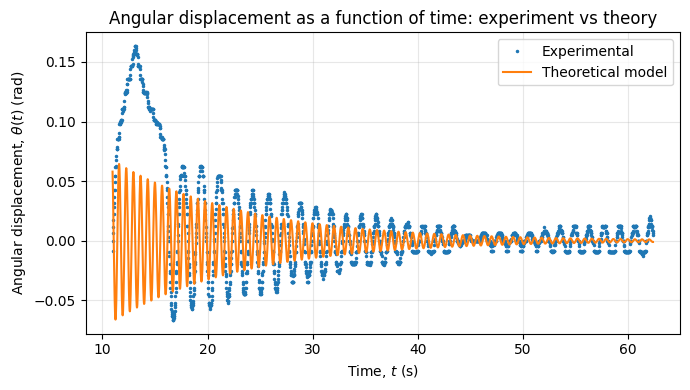

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(tv, thv, '.', ms=3, label='Experimental')
plt.plot(tv, theta_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Angular displacement, $\theta(t)$ (rad)')
plt.title(r'Angular displacement as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('theta_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

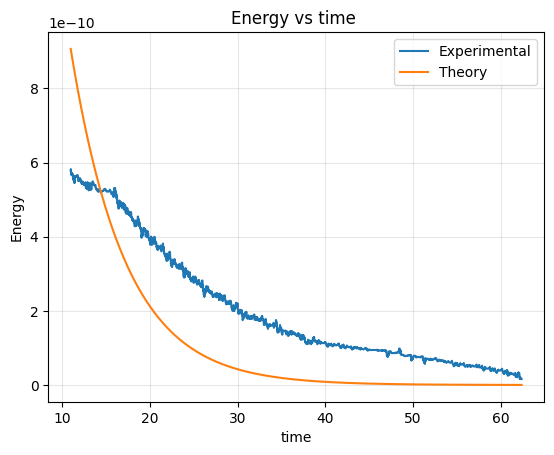

In [ ]:
omega_theory = np.gradient(theta_theory)
energy_0 = 0.5 * kappa * (theta_theory_max**2)

energy_theory = energy_0* np.exp(-2 * decay_rate*tv)

omega       = np.gradient(thv, tv)
omega_s     = savgol_filter(omega, window_length=21, polyorder=3)
energy_experimental = U_theta_shifted + 0.5*I*omega_s**2

# Formatting
plt.xlabel('time')
plt.ylabel('Energy')
plt.title('Energy vs time ')
plt.plot(tv, energy_experimental, label = "Experimental")
plt.plot(tv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()


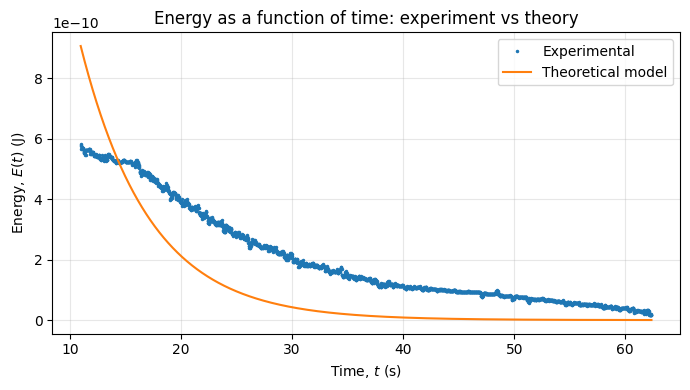

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(tv, energy_experimental, '.', ms=3, label='Experimental')
plt.plot(tv, energy_theory, '-', lw=1.5, label='Theoretical model')

plt.xlabel(r'Time, $t$ (s)')
plt.ylabel(r'Energy, $E(t)$ (J)')
plt.title(r'Energy as a function of time: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('energy_vs_time_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

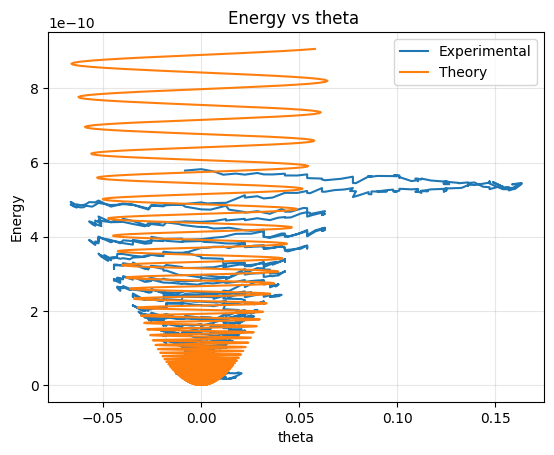

In [ ]:
# Formatting
plt.xlabel('theta')
plt.ylabel('Energy')
plt.title('Energy vs theta ')
plt.plot(thv, energy_experimental, label = "Experimental")
plt.plot(theta_theory, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

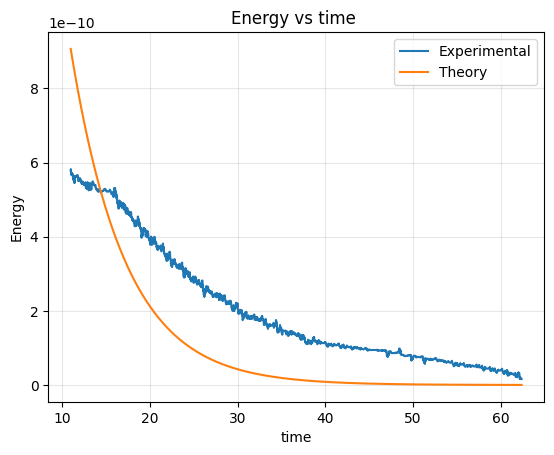

In [ ]:
plt.xlabel('time')
plt.ylabel('Energy')
plt.title('Energy vs time ')
plt.plot(tv, energy_experimental, label = "Experimental")
plt.plot(tv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

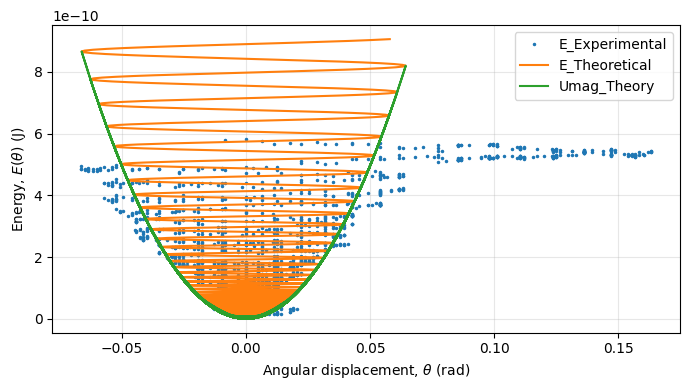

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(thv, energy_experimental, '.', ms=3, label='E_Experimental')
plt.plot(theta_theory, energy_theory, '-', lw=1.5, label='E_Theoretical')
plt.plot(theta_theory, U_theory, '-', lw=1.5, label='Umag_Theory')

plt.xlabel(r'Angular displacement, $\theta$ (rad)')
plt.ylabel(r'Energy, $E(\theta)$ (J)')
#plt.title(r'Energy as a function of angle: experiment vs theory')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('energy_vs_angle_experiment_vs_theory.png',
            dpi=400, bbox_inches='tight')
plt.show()

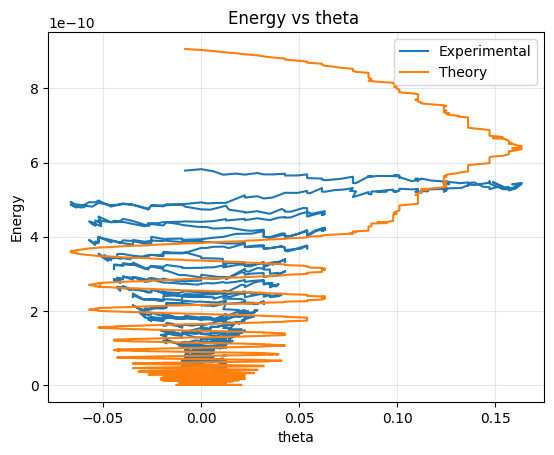

In [ ]:
plt.xlabel('theta')
plt.ylabel('Energy')
plt.title('Energy vs theta ')
plt.plot(thv, energy_experimental, label = "Experimental")
plt.plot(thv, energy_theory, label = "Theory")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()